# Phase 1: Data Understanding & EDA

1. Load dataset and inspect shape, dtypes, nulls
2. Visualize fraud vs. non-fraud ratio
3. Analyze transaction amounts, time patterns, and feature distributions
4. Correlation heatmap to find relationships

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')

In [8]:
# Load dataset
import os
data_path = '../data/creditcard.csv'
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print("Shape:", df.shape)
    display(df.head())
else:
    print("Dataset not found. Please download creditcard.csv and place it in the data/ folder.")

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Data Shape & Nulls

In [9]:
if 'df' in locals():
    print("Null values:\n", df.isnull().sum().max())
    print("\nData Types:\n", df.dtypes.value_counts())

Null values:
 0

Data Types:
 float64    30
int64       1
Name: count, dtype: int64


## 2. Fraud Ratio

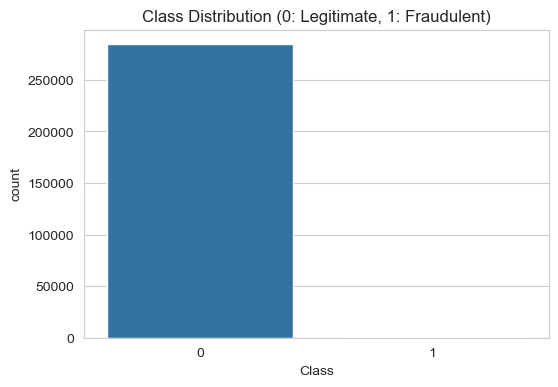

Fraudulent transactions make up 0.173% of the dataset.


In [10]:
if 'df' in locals():
    plt.figure(figsize=(6,4))
    sns.countplot(x='Class', data=df)
    plt.title('Class Distribution (0: Legitimate, 1: Fraudulent)')
    plt.show()
    
    fraud_ratio = df['Class'].value_counts(normalize=True)[1] * 100
    print(f"Fraudulent transactions make up {fraud_ratio:.3f}% of the dataset.")

## 3. Transaction Amount & Time

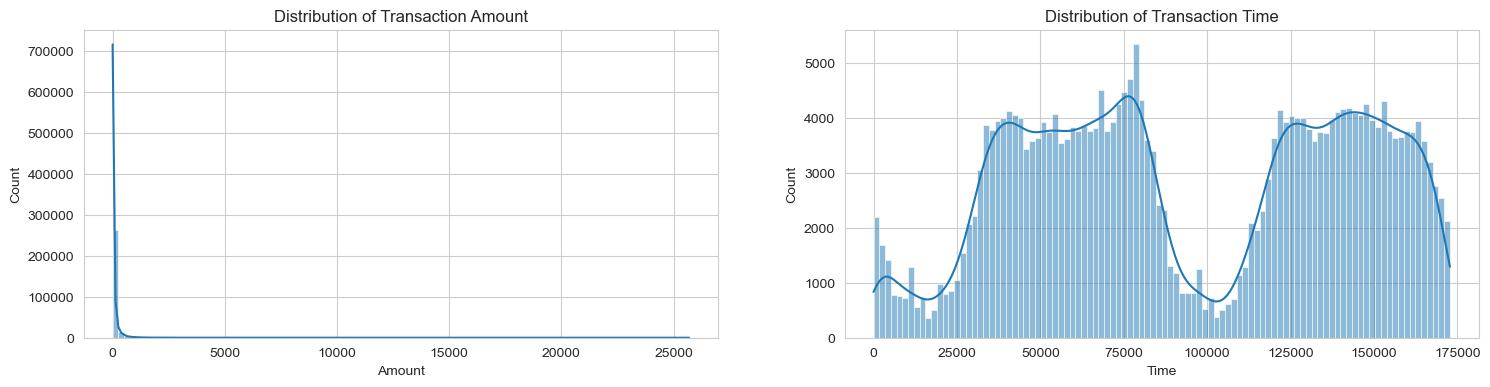

In [11]:
if 'df' in locals():
    fig, ax = plt.subplots(1, 2, figsize=(18,4))
    sns.histplot(df['Amount'], bins=100, ax=ax[0], kde=True)
    ax[0].set_title('Distribution of Transaction Amount')
    
    sns.histplot(df['Time'], bins=100, ax=ax[1], kde=True)
    ax[1].set_title('Distribution of Transaction Time')
    plt.show()

## 4. Correlation Heatmap

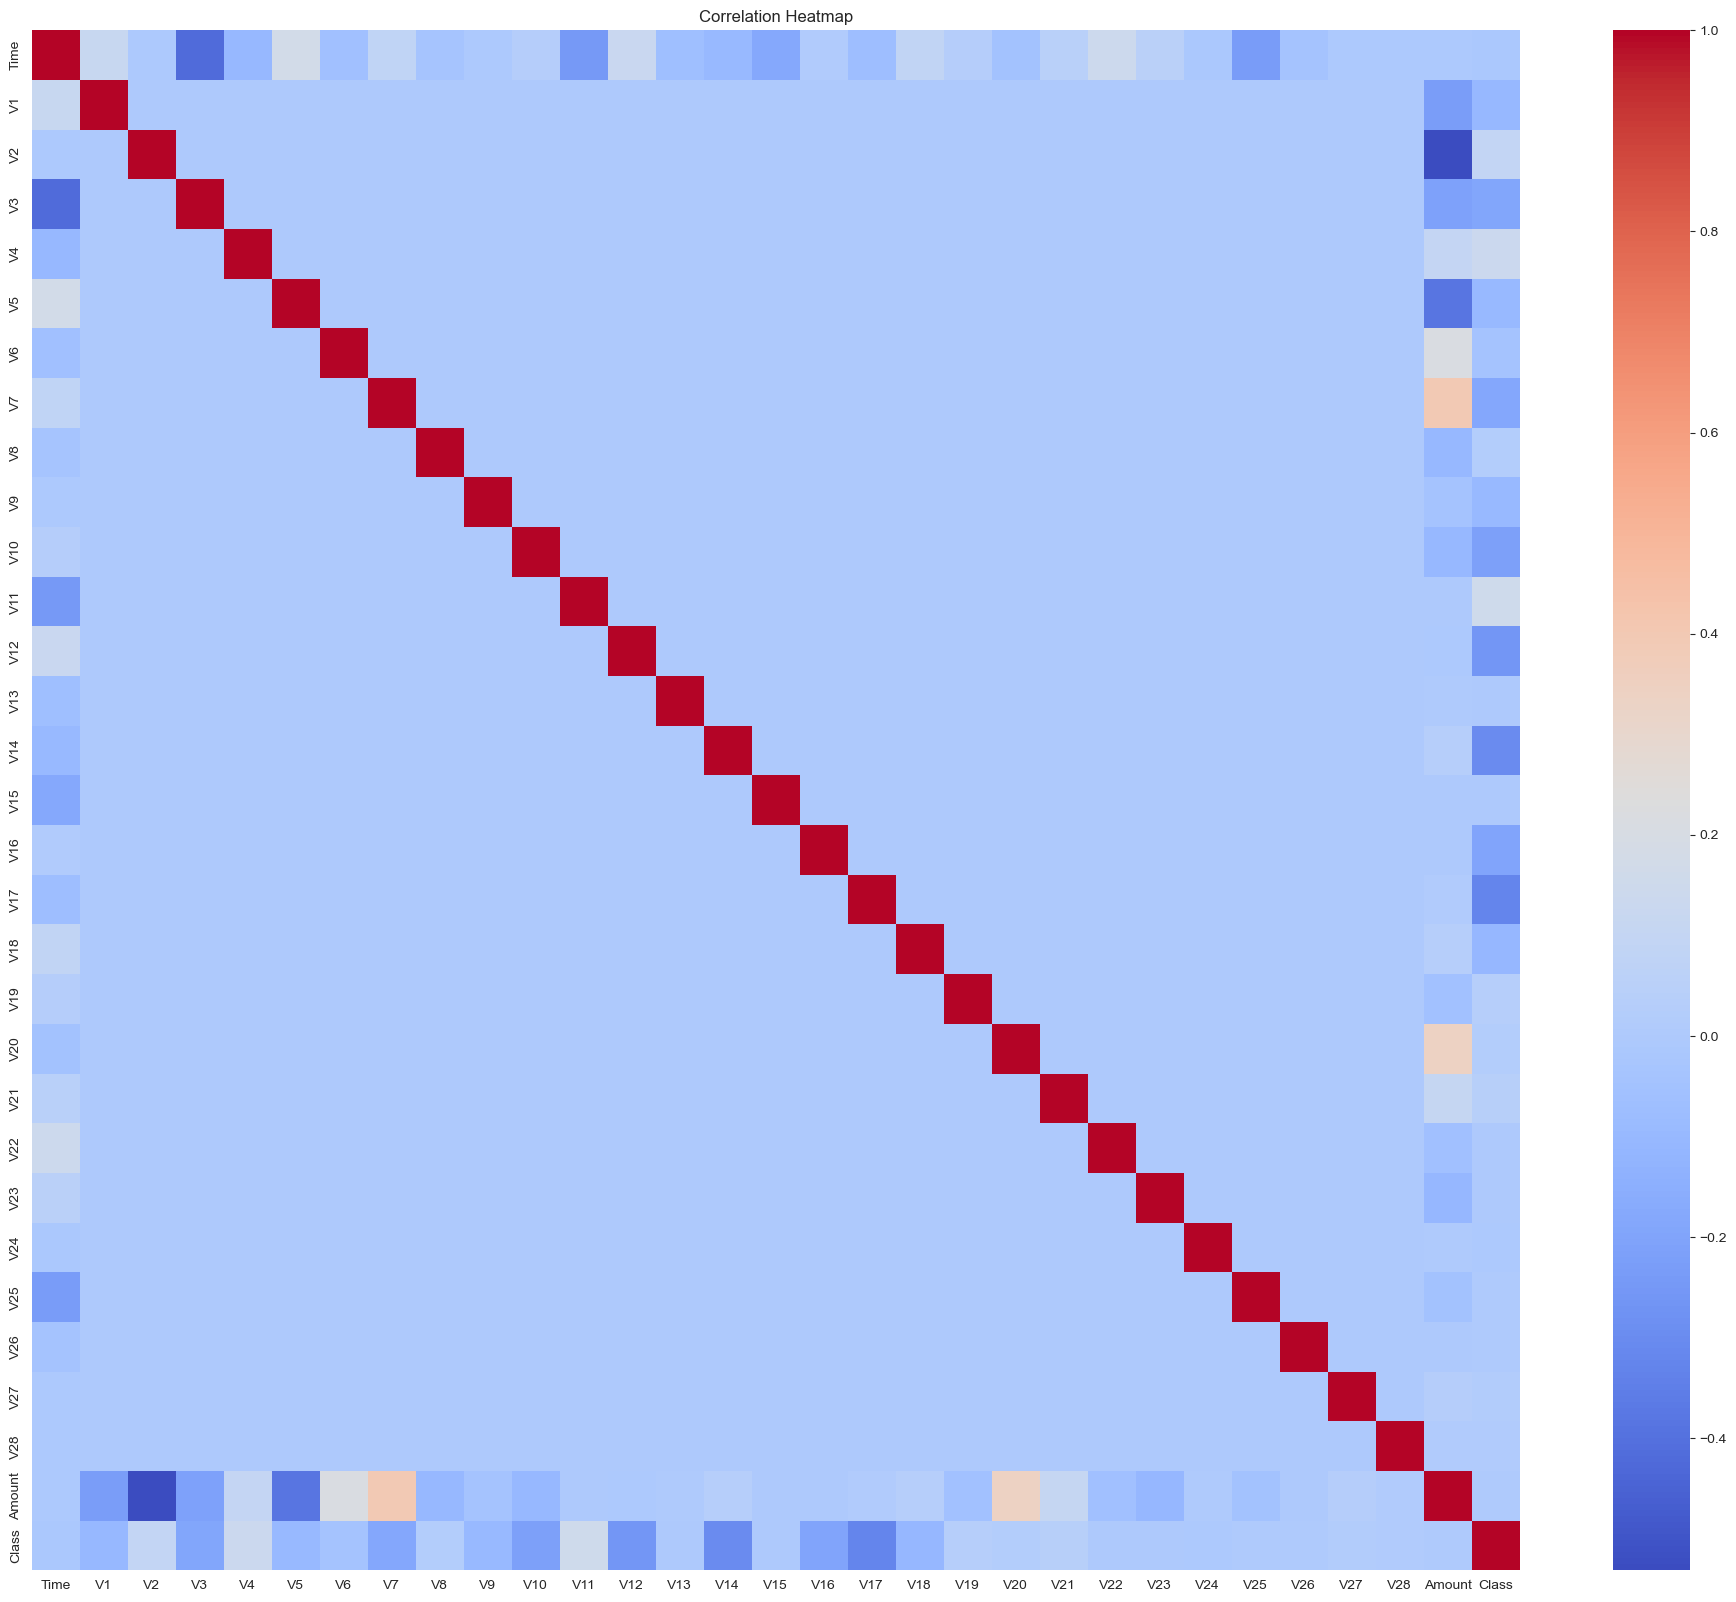

In [12]:
if 'df' in locals():
    plt.figure(figsize=(24,20))
    sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
    plt.title('Correlation Heatmap')
    plt.show()